This notebook calculates HLD for a given range of one of surfactant-containign system properties (Cc, EACN, Temperature, Salinity) and plots tubes with different emulsion types versus this property

In [1]:
import numpy as np
import pandas as pd
import ipywidgets as widgets
from IPython.display import display
#import matplotlib.pyplot as plt
#import matplotlib.patches as patches
from functions_for_surfactants import draw_type_1, draw_type_2, draw_type_3, draw_tubes, HLD_calculation

Choose a variable, that will be varied during calculation process and enter its range

In [2]:
variable_selection = widgets.Dropdown(options = ['', 'Cc', 'EACN', 'Salinity', 'Temperature'], value = '')
variable_selection

Dropdown(options=('', 'Cc', 'EACN', 'Salinity', 'Temperature'), value='')

In [3]:
varied_value = (float(input('Enter first range value of {}'.format(variable_selection.value))), 
                float(input('Enter end range value of {}'.format(variable_selection.value))))
varied_value_range = np.linspace(varied_value[0], varied_value[1], 10)

Enter first range value of Cc -1.6
Enter end range value of Cc 1.6


Enter values of other parameters of the system

In [4]:
if variable_selection.value == 'EACN':
    Cc = float(input('Enter Cc value'))
    Sal = float(input('Enter salinity value'))
    Temp = float(input('Enter temperature value'))
elif variable_selection.value == 'Cc':
    EACN = float(input('Enter EACN value'))
    Sal = float(input('Enter salinity value'))
    Temp = float(input('Enter temperature value'))
elif variable_selection.value == 'Temperature':
    Cc = float(input('Enter Cc value'))
    Sal = float(input('Enter salinity value'))
    EACN = float(input('Enter EACN value'))
elif variable_selection.value == 'Salinity':
    Cc = float(input('Enter Cc value'))
    Temp = float(input('Enter temperature'))
    EACN = float(input('Enter EACN value'))

Enter EACN value 8
Enter salinity value 3.4
Enter temperature value 25


Choose surfactant type

In [5]:
surfactant_selection = widgets.Dropdown(options = ['', 'Ionic', 'Nonionic', 'Zwitterionic'], value = '')
surfactant_selection



Dropdown(options=('', 'Ionic', 'Nonionic', 'Zwitterionic'), value='')

Correction for the concentration of unbound counerion of surfactant

In [7]:
if surfactant_selection.value == 'Ionic':
    conc = float(input('Enter connetration of surfactant in mol/L'))
    MW = float(input('Enter MW of the counterion'))
    Cor = 0.3 * (conc/10)*MW
else:
    Cor = 0

Enter connetration of surfactant in mol/L 0.3
Enter MW of the counterion 25.5


Calculate HLDs and draw tubes

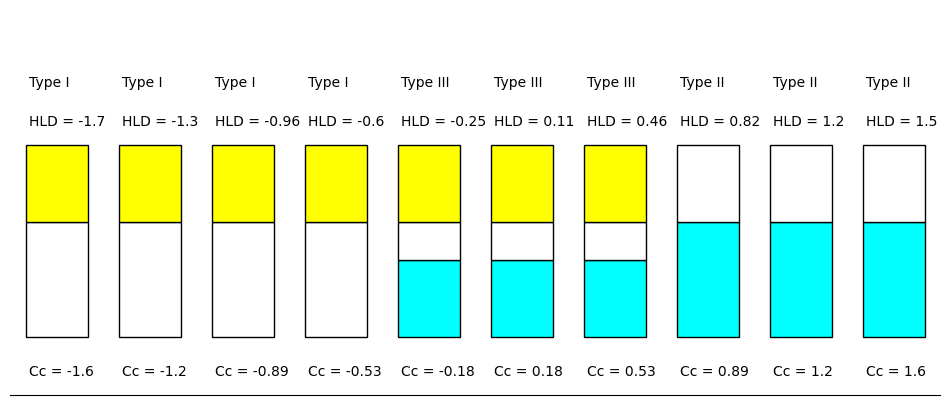

In [8]:
if variable_selection.value == 'EACN':
    HLDs = HLD_calculation(EACN = varied_value_range, Cc = Cc, Sal = Sal, Temp = Temp, Type = surfactant_selection.value, Cor = Cor)
elif variable_selection.value == 'Cc':
    HLDs = HLD_calculation(EACN = EACN, Cc = varied_value_range, Sal = Sal, Temp = Temp, Type = surfactant_selection.value, Cor = Cor)
elif variable_selection.value == 'Temp':
    HLDs = HLD_calculation(EACN = EACN, Cc = Cc, Sal = Sal, Temp = varied_value_range, Type = surfactant_selection.value, Cor = Cor)
elif variable_selection.value == 'Sal':
    HLDs = HLD_calculation(EACN = EACN, Cc = Cc, Sal = varied_value_range, Temp = Temp, Type = surfactant_selection.value, Cor = Cor)

fig = draw_tubes(HLDs, varied_value_range, variable_selection.value)
